# Guía 5 — Problema 3*: sistemas dinámicos no lineales en dos dimensiones

## Introducción

Los sistemas dinámicos no lineales pueden presentar varios comportamientos cualitativos aun cuando solo poseen dos variables: convergencia hacia estados estacionarios, puntos silla, oscilaciones, espirales y separatrices que dividen regiones con evoluciones diferentes.

En este ejercicio analizamos cuatro ejemplos mediante dos enfoques complementarios:

- **analítico:** nulclinas, puntos fijos, matriz jacobiana y autovalores;
- **numérico:** campos vectoriales, retratos de fase y trayectorias integradas con Runge–Kutta de orden cuatro.

El objetivo es comprobar que la geometría observada numéricamente coincide con la clasificación local obtenida a partir del Jacobiano.

## Sistemas estudiados

1. Sistema desacoplado con dos atractores:

$$
\dot{x}=x-x^3,
\qquad
\dot{y}=-y.
$$

2. Sistema con una silla y un foco inestable:

$$
\dot{x}=x-y,
\qquad
\dot{y}=x^2-4.
$$

3. Sistema con una silla y un foco estable:

$$
\dot{x}=x(2-x-y),
\qquad
\dot{y}=x-y.
$$

4. Péndulo no lineal sin rozamiento:

$$
\dot{\theta}=\omega,
\qquad
\dot{\omega}=-\frac{g}{l}\sin\theta.
$$

Para cada caso determinaremos nulclinas, puntos fijos y estabilidad, y luego interpretaremos su retrato de fases.

## Estrategia general de resolución

Para un sistema autónomo

$$
\dot{x}=f(x,y),
\qquad
\dot{y}=g(x,y),
$$

seguimos los siguientes pasos.

### 1. Nulclinas

Las nulclinas son las curvas donde una de las componentes del campo se anula:

$$
f(x,y)=0
\quad\text{y}\quad
g(x,y)=0.
$$

Sobre la primera, el movimiento instantáneo es vertical; sobre la segunda, es horizontal. Sus intersecciones son los puntos fijos.

### 2. Linealización

Alrededor de un punto fijo $(x^*,y^*)$ utilizamos el Jacobiano

$$
J(x,y)=
\begin{pmatrix}
\partial f/\partial x & \partial f/\partial y\\
\partial g/\partial x & \partial g/\partial y
\end{pmatrix}.
$$

Los autovalores de $J(x^*,y^*)$ determinan la estabilidad local:

| Autovalores | Clasificación |
|---|---|
| ambos reales y negativos | nodo estable |
| ambos reales y positivos | nodo inestable |
| signos opuestos | punto silla |
| complejos con parte real negativa | foco estable |
| complejos con parte real positiva | foco inestable |
| imaginarios puros | la linealización no basta; se busca una cantidad conservada |

### 3. Comparación numérica

Finalmente integramos varias condiciones iniciales. Las nulclinas ayudan a interpretar el sentido del campo, mientras que las trayectorias permiten reconocer atractores, espirales y separatrices.

## Herramientas numéricas comunes

La siguiente celda implementa RK4 y una función reutilizable para los cuatro retratos de fase. Cada gráfico combina:

- flechas normalizadas, que muestran la dirección local del campo;
- líneas de corriente, que revelan la geometría global;
- nulclinas y puntos fijos;
- trayectorias obtenidas por integración numérica.

Cuando resulta útil se integra tanto hacia tiempos positivos como negativos. La integración hacia atrás no representa una evolución física nueva: se usa para reconstruir visualmente las variedades que llegan o salen de un punto silla.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def rk4(f, z0, t):
    """
    Integra z' = f(t,z) usando Runge-Kutta de orden 4.
    """
    z = np.zeros((len(t), len(z0)), dtype=float)
    z[0] = np.array(z0, dtype=float)

    for n in range(len(t)-1):
        h = t[n+1] - t[n]
        tn = t[n]
        zn = z[n]

        k1 = np.array(f(tn, zn))
        k2 = np.array(f(tn + h/2, zn + h*k1/2))
        k3 = np.array(f(tn + h/2, zn + h*k2/2))
        k4 = np.array(f(tn + h, zn + h*k3))

        z[n+1] = zn + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

    return z


def plot_phase_portrait(
    f,
    xlim,
    ylim,
    fixed_points=None,
    nullcline_curves=None,
    trajectories=None,
    title="Diagrama de fases",
    xlabel=r"$x$",
    ylabel=r"$y$",
    density=1.2,
    grid_points=31,
    tmax=6,
    both_time_directions=True
):
    x = np.linspace(xlim[0], xlim[1], grid_points)
    y = np.linspace(ylim[0], ylim[1], grid_points)
    X, Y = np.meshgrid(x, y)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            dx, dy = f(0, [X[i, j], Y[i, j]])
            U[i, j] = dx
            V[i, j] = dy

    N = np.sqrt(U**2 + V**2)
    U_norm = U / (N + 1e-12)
    V_norm = V / (N + 1e-12)

    plt.figure(figsize=(8, 7))
    plt.quiver(X, Y, U_norm, V_norm, alpha=0.55)
    plt.streamplot(X, Y, U, V, density=density, linewidth=1)

    if nullcline_curves is not None:
        for curve in nullcline_curves:
            plt.plot(curve["x"], curve["y"], linewidth=2.5, label=curve.get("label", "nulclina"))

    if fixed_points is not None:
        for p in fixed_points:
            plt.scatter([p[0]], [p[1]], s=90, color="black", zorder=5)
            plt.text(p[0], p[1], f"  ({p[0]:.2g},{p[1]:.2g})", fontsize=10)

    if trajectories is not None:
        t_forward = np.linspace(0, tmax, 700)
        t_backward = np.linspace(0, -tmax, 700)
        for z0 in trajectories:
            sol_f = rk4(f, z0, t_forward)
            plt.plot(sol_f[:, 0], sol_f[:, 1], linewidth=2)
            if both_time_directions:
                sol_b = rk4(f, z0, t_backward)
                plt.plot(sol_b[:, 0], sol_b[:, 1], linewidth=2)

    plt.axhline(0, linewidth=0.8, color="black")
    plt.axvline(0, linewidth=0.8, color="black")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(False)
    plt.show()

## Sistema 1

$$
\dot{x}=x-x^3,
\qquad
\dot{y}=-y.
$$

### Nulclinas

Para la nulclina de \(x\):

$$
\dot{x}=0
\quad\Longrightarrow\quad
x-x^3=0.
$$

Factorizando:

$$
x(1-x^2)=0.
$$

Entonces:

$$
x=-1,
\qquad
x=0,
\qquad
x=1.
$$

Para la nulclina de \(y\):

$$
\dot{y}=0
\quad\Longrightarrow\quad
-y=0.
$$

Entonces:

$$
y=0.
$$

### Puntos fijos

Los puntos fijos son las intersecciones entre las nulclinas:

$$
(-1,0),
\qquad
(0,0),
\qquad
(1,0).
$$

### Jacobiano

Definimos:

$$
f(x,y)=x-x^3,
\qquad
g(x,y)=-y.
$$

El Jacobiano es:

$$
J(x,y)=
\begin{pmatrix}
1-3x^2 & 0\\
0 & -1
\end{pmatrix}.
$$

### Estabilidad

En \((-1,0)\):

$$
J(-1,0)=
\begin{pmatrix}
-2 & 0\\
0 & -1
\end{pmatrix}.
$$

Los autovalores son \(-2\) y \(-1\). Entonces:

$$
\boxed{(-1,0)\text{ es un nodo estable.}}
$$

En \((0,0)\):

$$
J(0,0)=
\begin{pmatrix}
1 & 0\\
0 & -1
\end{pmatrix}.
$$

Los autovalores son \(1\) y \(-1\). Entonces:

$$
\boxed{(0,0)\text{ es un punto silla.}}
$$

En \((1,0)\):

$$
J(1,0)=
\begin{pmatrix}
-2 & 0\\
0 & -1
\end{pmatrix}.
$$

Los autovalores son \(-2\) y \(-1\). Entonces:

$$
\boxed{(1,0)\text{ es un nodo estable.}}
$$

### Interpretación

La variable \(y\) siempre tiende a cero porque \(\dot{y}=-y\). La variable \(x\) se comporta como el sistema 1D \(\dot{x}=x-x^3\). Por eso los atractores son \((-1,0)\) y \((1,0)\), mientras que \((0,0)\) es una silla.

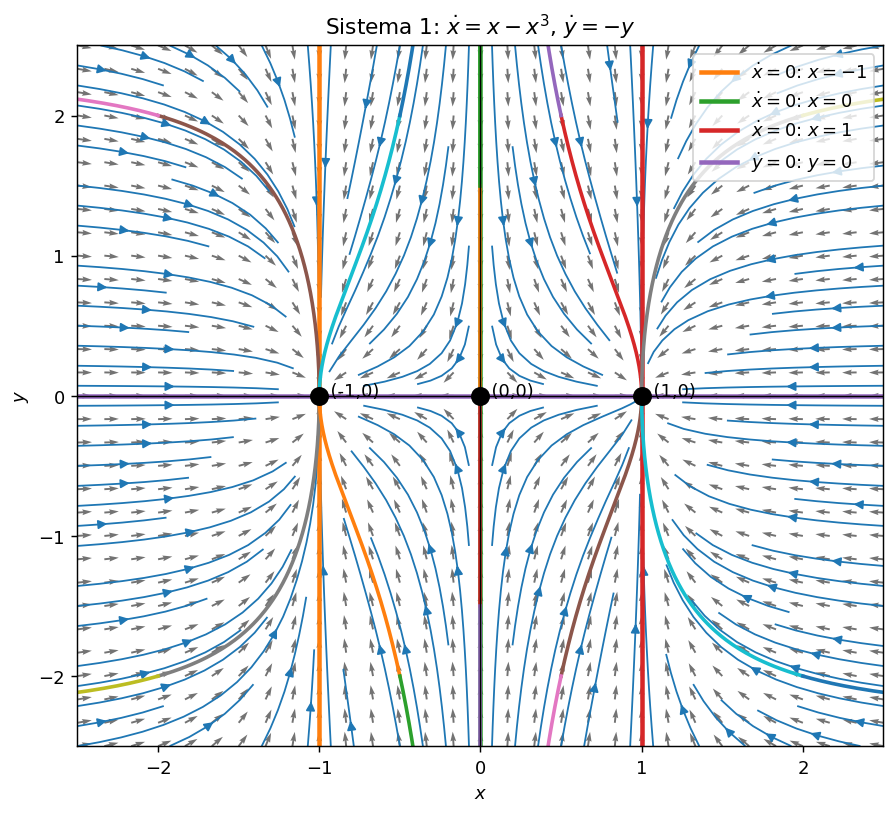

In [2]:
# Sistema 1: x' = x - x^3, y' = -y

def sistema_1(t, z):
    x, y = z
    return [x - x**3, -y]

fixed_points_1 = [(-1, 0), (0, 0), (1, 0)]

xx = np.linspace(-2.5, 2.5, 400)
yy = np.linspace(-2.5, 2.5, 400)

nullclines_1 = [
    {"x": -np.ones_like(yy), "y": yy, "label": r"$\dot{x}=0$: $x=-1$"},
    {"x": np.zeros_like(yy), "y": yy, "label": r"$\dot{x}=0$: $x=0$"},
    {"x": np.ones_like(yy), "y": yy, "label": r"$\dot{x}=0$: $x=1$"},
    {"x": xx, "y": np.zeros_like(xx), "label": r"$\dot{y}=0$: $y=0$"},
]

trajectories_1 = [
    [-2, 2], [-2, -2],
    [-0.5, 2], [-0.5, -2],
    [0.5, 2], [0.5, -2],
    [2, 2], [2, -2],
    [0, 1.5], [0, -1.5],
]

plot_phase_portrait(
    sistema_1,
    xlim=(-2.5, 2.5),
    ylim=(-2.5, 2.5),
    fixed_points=fixed_points_1,
    nullcline_curves=nullclines_1,
    trajectories=trajectories_1,
    title=r"Sistema 1: $\dot{x}=x-x^3$, $\dot{y}=-y$",
    tmax=6
)

### Lectura del retrato de fase

El cálculo numérico confirma la clasificación analítica:

- si $x(0)>0$, las trayectorias tienden a $(1,0)$;
- si $x(0)<0$, tienden a $(-1,0)$;
- la recta $x=0$ es invariante y constituye la variedad estable de la silla $(0,0)$.

Por lo tanto, $x=0$ actúa como separatriz entre las cuencas de atracción de los dos nodos estables. La caída exponencial de $y$ lleva todas las trayectorias hacia el eje horizontal.

## Sistema 2

$$
\dot{x}=x-y,
\qquad
\dot{y}=x^2-4.
$$

### Nulclinas

Para la nulclina de \(x\):

$$
\dot{x}=0
\quad\Longrightarrow\quad
x-y=0.
$$

Entonces:

$$
y=x.
$$

Para la nulclina de \(y\):

$$
\dot{y}=0
\quad\Longrightarrow\quad
x^2-4=0.
$$

Entonces:

$$
x=\pm 2.
$$

### Puntos fijos

Intersecciones de \(y=x\) con \(x=\pm2\):

$$
(-2,-2),
\qquad
(2,2).
$$

### Jacobiano

Definimos:

$$
f(x,y)=x-y,
\qquad
g(x,y)=x^2-4.
$$

Entonces:

$$
J(x,y)=
\begin{pmatrix}
1 & -1\\
2x & 0
\end{pmatrix}.
$$

### Estabilidad

En \((2,2)\):

$$
J(2,2)=
\begin{pmatrix}
1 & -1\\
4 & 0
\end{pmatrix}.
$$

El polinomio característico es:

$$
\lambda^2-\lambda+4=0.
$$

Por lo tanto:

$$
\lambda=\frac{1}{2}\pm i\frac{\sqrt{15}}{2}.
$$

Como la parte real es positiva:

$$
\boxed{(2,2)\text{ es un foco inestable.}}
$$

En \((-2,-2)\):

$$
J(-2,-2)=
\begin{pmatrix}
1 & -1\\
-4 & 0
\end{pmatrix}.
$$

El polinomio característico es:

$$
\lambda^2-\lambda-4=0.
$$

Por lo tanto:

$$
\lambda=\frac{1\pm\sqrt{17}}{2}.
$$

Hay un autovalor positivo y otro negativo, entonces:

$$
\boxed{(-2,-2)\text{ es un punto silla.}}
$$

### Interpretación

Cerca de \((-2,-2)\), las trayectorias tienen comportamiento de silla. Cerca de \((2,2)\), las trayectorias giran alejándose del punto fijo, porque es un foco inestable.

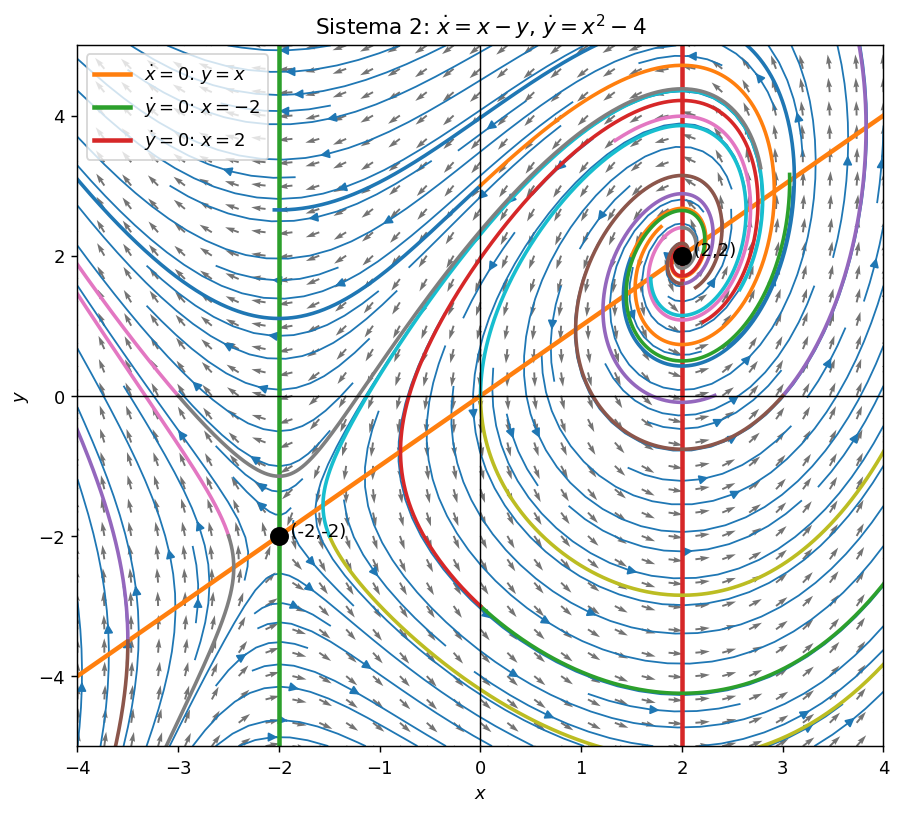

In [3]:
# Sistema 2: x' = x - y, y' = x^2 - 4

def sistema_2(t, z):
    x, y = z
    return [x - y, x**2 - 4]

fixed_points_2 = [(-2, -2), (2, 2)]

xx = np.linspace(-4, 4, 400)
yy = np.linspace(-5, 5, 400)

nullclines_2 = [
    {"x": xx, "y": xx, "label": r"$\dot{x}=0$: $y=x$"},
    {"x": -2*np.ones_like(yy), "y": yy, "label": r"$\dot{y}=0$: $x=-2$"},
    {"x": 2*np.ones_like(yy), "y": yy, "label": r"$\dot{y}=0$: $x=2$"},
]

trajectories_2 = [
    [-3.5, -3.5], [-2.5, -2], [-1.5, -2],
    [1.5, 2.0], [2.2, 2.0], [2.0, 1.6], [2.0, 2.4],
    [0, 0], [0, 3], [0, -3],
    [3, 0], [-3, 0]
]

plot_phase_portrait(
    sistema_2,
    xlim=(-4, 4),
    ylim=(-5, 5),
    fixed_points=fixed_points_2,
    nullcline_curves=nullclines_2,
    trajectories=trajectories_2,
    title=r"Sistema 2: $\dot{x}=x-y$, $\dot{y}=x^2-4$",
    tmax=3.5
)

### Lectura del retrato de fase

Las trayectorias próximas a $(-2,-2)$ se acercan por una dirección y se alejan por otra, comportamiento característico de una silla. Alrededor de $(2,2)$ giran mientras se alejan, de acuerdo con los autovalores complejos de parte real positiva.

Como ninguno de los dos puntos es atractor, una trayectoria genérica no converge a un estado estacionario y puede abandonar la región representada.

## Sistema 3

$$
\dot{x}=x(2-x-y),
\qquad
\dot{y}=x-y.
$$

### Nulclinas

Para la nulclina de \(x\):

$$
\dot{x}=0
\quad\Longrightarrow\quad
x(2-x-y)=0.
$$

Entonces:

$$
x=0,
\qquad
2-x-y=0.
$$

La segunda ecuación se escribe como:

$$
y=2-x.
$$

Para la nulclina de \(y\):

$$
\dot{y}=0
\quad\Longrightarrow\quad
x-y=0.
$$

Entonces:

$$
y=x.
$$

### Puntos fijos

Intersección de \(x=0\) con \(y=x\):

$$
(0,0).
$$

Intersección de \(y=2-x\) con \(y=x\):

$$
x=2-x,
$$

entonces:

$$
x=1,
\qquad
y=1.
$$

Por lo tanto:

$$
(0,0),
\qquad
(1,1).
$$

### Jacobiano

Definimos:

$$
f(x,y)=x(2-x-y)=2x-x^2-xy,
\qquad
g(x,y)=x-y.
$$

Entonces:

$$
J(x,y)=
\begin{pmatrix}
2-2x-y & -x\\
1 & -1
\end{pmatrix}.
$$

### Estabilidad

En \((0,0)\):

$$
J(0,0)=
\begin{pmatrix}
2 & 0\\
1 & -1
\end{pmatrix}.
$$

Los autovalores son:

$$
\lambda_1=2,
\qquad
\lambda_2=-1.
$$

Entonces:

$$
\boxed{(0,0)\text{ es un punto silla.}}
$$

En \((1,1)\):

$$
J(1,1)=
\begin{pmatrix}
-1 & -1\\
1 & -1
\end{pmatrix}.
$$

El polinomio característico es:

$$
(\lambda+1)^2+1=0.
$$

Entonces:

$$
\lambda=-1\pm i.
$$

Como la parte real es negativa:

$$
\boxed{(1,1)\text{ es un foco estable.}}
$$

### Interpretación

El punto \((0,0)\) es una silla. El punto \((1,1)\) es un foco estable. En muchas condiciones iniciales con \(x>0\), las trayectorias terminan girando hacia \((1,1)\).

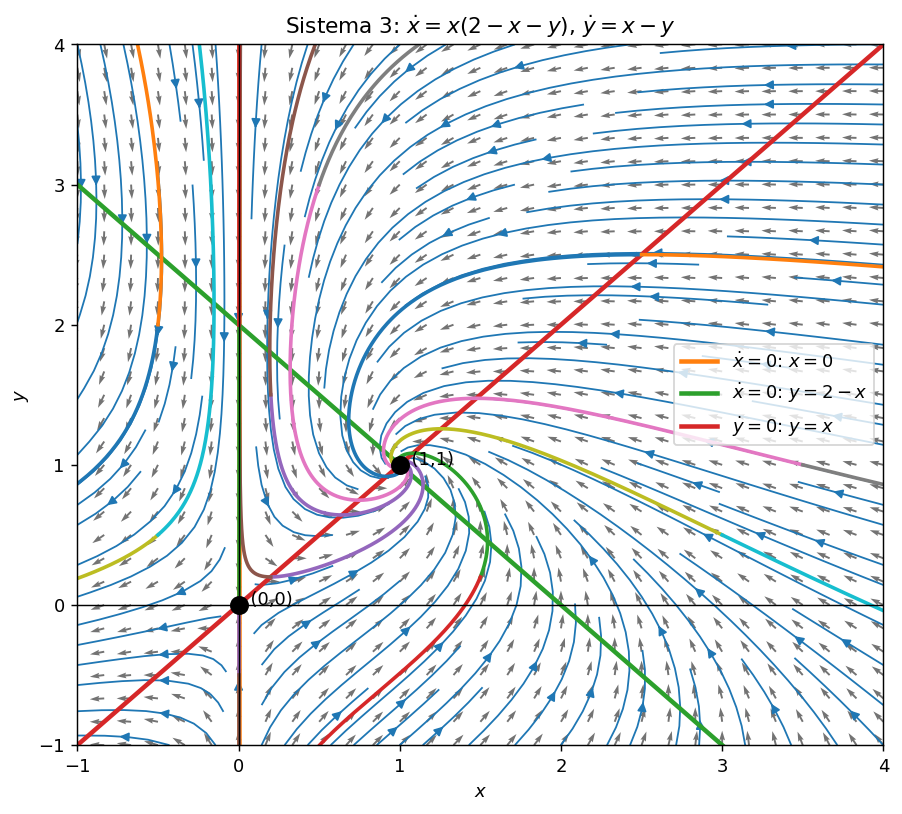

In [4]:
# Sistema 3: x' = x(2-x-y), y' = x-y

def sistema_3(t, z):
    x, y = z
    return [x*(2 - x - y), x - y]

fixed_points_3 = [(0, 0), (1, 1)]

xx = np.linspace(-1, 4, 400)
yy = np.linspace(-1, 4, 400)

nullclines_3 = [
    {"x": np.zeros_like(yy), "y": yy, "label": r"$\dot{x}=0$: $x=0$"},
    {"x": xx, "y": 2 - xx, "label": r"$\dot{x}=0$: $y=2-x$"},
    {"x": xx, "y": xx, "label": r"$\dot{y}=0$: $y=x$"},
]

trajectories_3 = [
    [0.2, 0.2], [0.5, 3], [3, 0.5], [2.5, 2.5],
    [1.5, 0.2], [0.2, 1.5], [3.5, 1],
    [-0.5, 0.5], [-0.5, 2],
    [0, 2], [0, -0.5]
]

plot_phase_portrait(
    sistema_3,
    xlim=(-1, 4),
    ylim=(-1, 4),
    fixed_points=fixed_points_3,
    nullcline_curves=nullclines_3,
    trajectories=trajectories_3,
    title=r"Sistema 3: $\dot{x}=x(2-x-y)$, $\dot{y}=x-y$",
    tmax=8
)

### Lectura del retrato de fase

La recta $x=0$ es invariante porque allí $\dot{x}=0$. Además, coincide localmente con la dirección estable de la silla $(0,0)$ y separa comportamientos cualitativamente distintos.

En el semiplano $x>0$, muchas trayectorias giran hacia $(1,1)$. La rotación y la disminución progresiva de su radio concuerdan con los autovalores $-1\pm i$ del foco estable.

## Sistema 4: Péndulo

La ecuación del péndulo es:

$$
\ddot{\theta}=-\frac{g}{l}\sin\theta.
$$

Definimos:

$$
\omega=\dot{\theta}.
$$

Entonces:

$$
\dot{\theta}=\omega,
\qquad
\dot{\omega}=-\frac{g}{l}\sin\theta.
$$

### Nulclinas

Para la nulclina de \(\theta\):

$$
\dot{\theta}=0
\quad\Longrightarrow\quad
\omega=0.
$$

Para la nulclina de \(\omega\):

$$
\dot{\omega}=0
\quad\Longrightarrow\quad
-\frac{g}{l}\sin\theta=0.
$$

Como \(g/l\neq0\):

$$
\sin\theta=0.
$$

Entonces:

$$
\theta=n\pi,
\qquad
n\in\mathbb{Z}.
$$

### Puntos fijos

Los puntos fijos son:

$$
\boxed{(\theta^*,\omega^*)=(n\pi,0),\qquad n\in\mathbb{Z}.}
$$

### Jacobiano

Definimos:

$$
f(\theta,\omega)=\omega,
\qquad
g(\theta,\omega)=-\frac{g}{l}\sin\theta.
$$

Entonces:

$$
J(\theta,\omega)=
\begin{pmatrix}
0 & 1\\
-\dfrac{g}{l}\cos\theta & 0
\end{pmatrix}.
$$

En los puntos fijos:

$$
J(n\pi,0)=
\begin{pmatrix}
0 & 1\\
-\dfrac{g}{l}\cos(n\pi) & 0
\end{pmatrix}.
$$

Como:

$$
\cos(n\pi)=(-1)^n,
$$

queda:

$$
J(n\pi,0)=
\begin{pmatrix}
0 & 1\\
-\dfrac{g}{l}(-1)^n & 0
\end{pmatrix}.
$$

### Estabilidad

Si \(n\) es par, \(n=2k\):

$$
\theta^*=2k\pi,
$$

entonces:

$$
J(2k\pi,0)=
\begin{pmatrix}
0 & 1\\
-\dfrac{g}{l} & 0
\end{pmatrix}.
$$

El polinomio característico es:

$$
\lambda^2+\frac{g}{l}=0.
$$

Por lo tanto:

$$
\lambda=\pm i\sqrt{\frac{g}{l}}.
$$

Entonces:

$$
\boxed{(2k\pi,0)\text{ es un centro estable no asintótico.}}
$$

Si \(n\) es impar, \(n=2k+1\):

$$
\theta^*=(2k+1)\pi,
$$

entonces:

$$
J((2k+1)\pi,0)=
\begin{pmatrix}
0 & 1\\
\dfrac{g}{l} & 0
\end{pmatrix}.
$$

El polinomio característico es:

$$
\lambda^2-\frac{g}{l}=0.
$$

Por lo tanto:

$$
\lambda=\pm\sqrt{\frac{g}{l}}.
$$

Entonces:

$$
\boxed{((2k+1)\pi,0)\text{ es un punto silla.}}
$$

### Interpretación

El péndulo sin rozamiento conserva la energía:

$$
E(\theta,\omega)=\frac{1}{2}\omega^2+\frac{g}{l}(1-\cos\theta).
$$

Las curvas cerradas alrededor de \((2k\pi,0)\) representan oscilaciones. Las curvas que pasan cerca de \(((2k+1)\pi,0)\) separan oscilaciones de rotaciones completas.

### Variables utilizadas en los gráficos

Para que el retrato no dependa de las unidades elegidas para $g$ y $l$, introducimos

$$
\tau=\sqrt{\frac{g}{l}}\,t,
\qquad
v=\frac{\omega}{\sqrt{g/l}}.
$$

En estas variables el sistema toma la forma normalizada

$$
\frac{d\theta}{d\tau}=v,
\qquad
\frac{dv}{d\tau}=-\sin\theta,
$$

y la energía adimensional es

$$
\mathcal E(\theta,v)=\frac12v^2+1-\cos\theta.
$$

La separatriz tiene energía $\mathcal E=2$ y corta el eje $\theta=0$ en $v=\pm2$. Esta normalización hace que las escalas horizontal y vertical se vean más equilibradas sin modificar la dinámica.

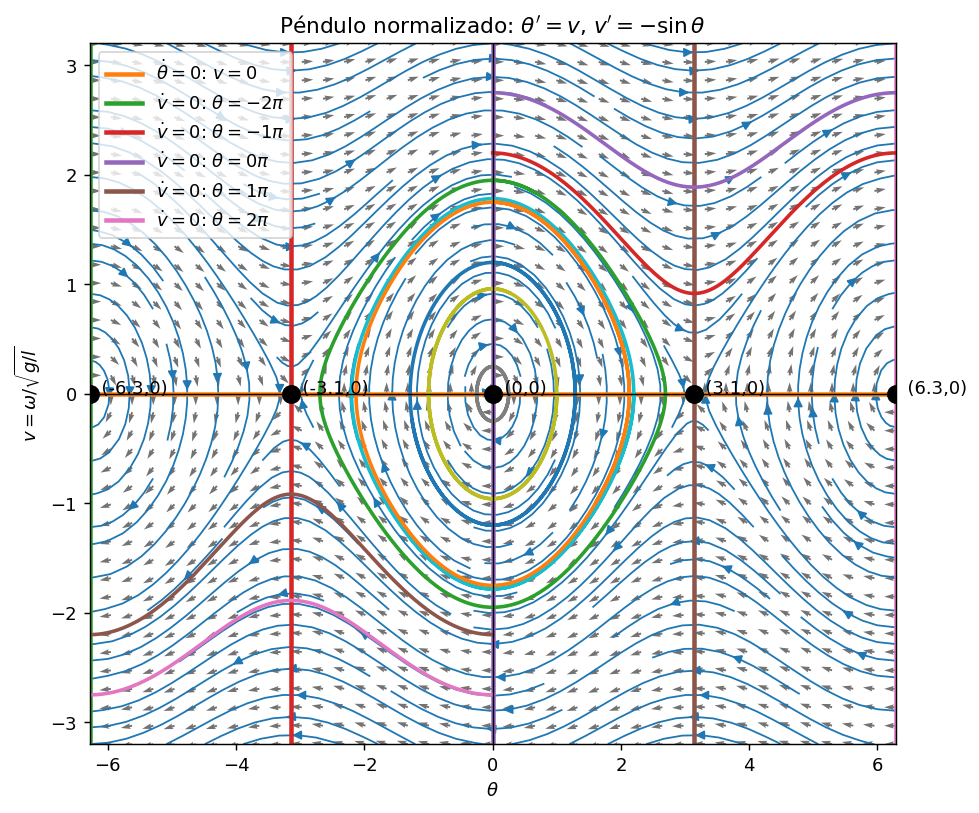

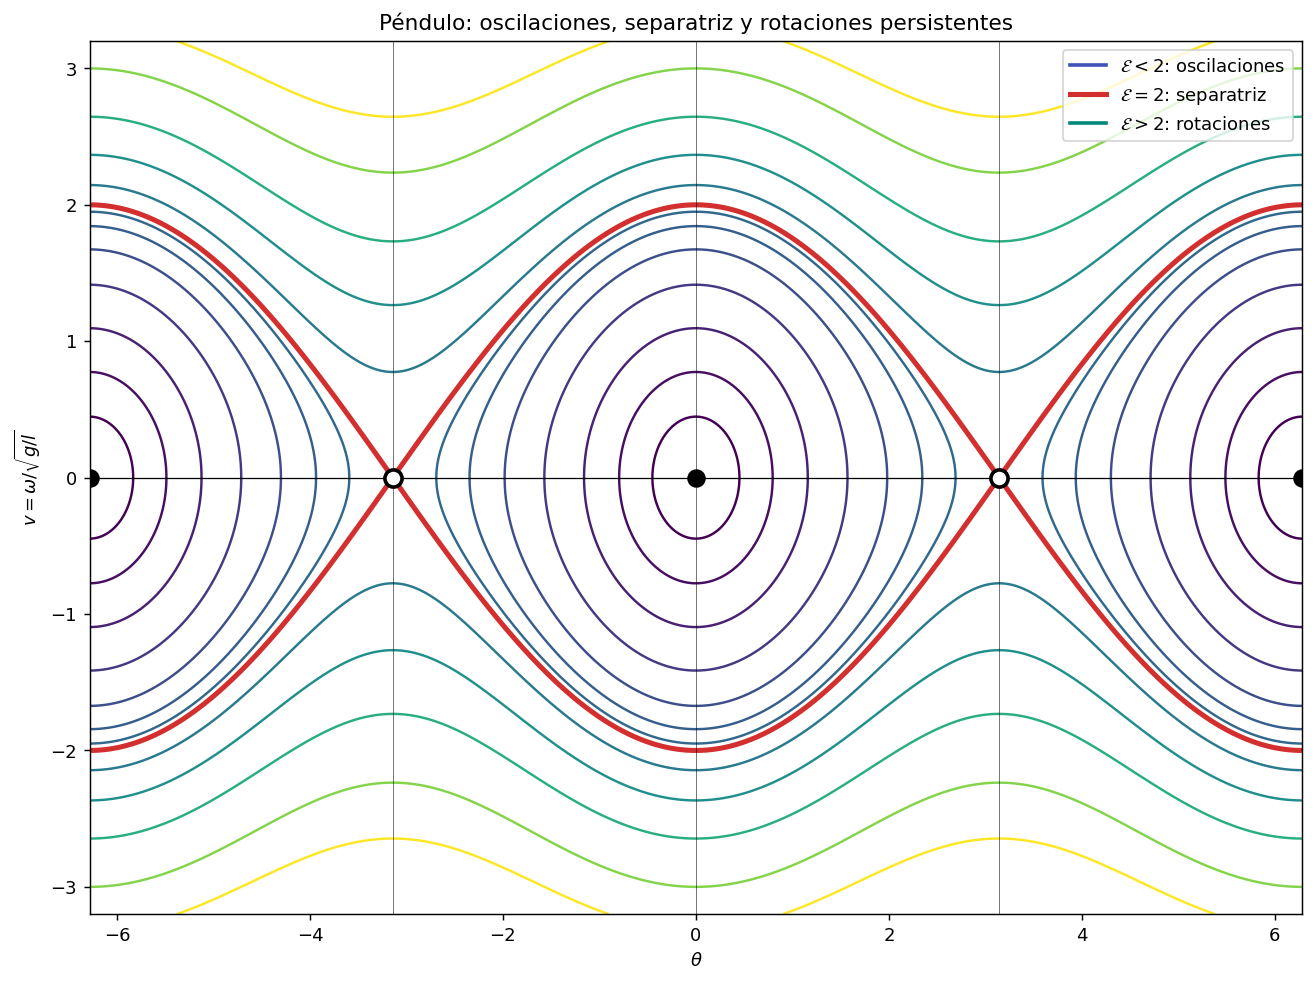

In [5]:
# Sistema 4 en variables normalizadas:
# dtheta/dtau = v, dv/dtau = -sin(theta)

def pendulo_normalizado(tau, z):
    theta, v = z
    return [v, -np.sin(theta)]


theta_min, theta_max = -2*np.pi, 2*np.pi
v_min, v_max = -3.2, 3.2

theta_vals = np.linspace(theta_min, theta_max, 900)
v_vals = np.linspace(v_min, v_max, 500)

fixed_points_pendulo = [
    (n*np.pi, 0)
    for n in range(-2, 3)
    if theta_min <= n*np.pi <= theta_max
]

nullclines_pendulo = [
    {"x": theta_vals, "y": np.zeros_like(theta_vals),
     "label": r"$\dot{\theta}=0$: $v=0$"}
]
for n in range(-2, 3):
    nullclines_pendulo.append({
        "x": n*np.pi*np.ones_like(v_vals),
        "y": v_vals,
        "label": rf"$\dot{{v}}=0$: $\theta={n}\pi$",
    })

# |v0|<2 en theta=0: oscilaciones cerradas.
# |v0|>2: rotaciones completas y persistentes.
trayectorias_pendulo = [
    [0.25, 0.0], [1.0, 0.0], [2.2, 0.0],
    [0.0, 1.2], [0.0, 1.75], [0.0, 1.95],
    [0.0, 2.20], [0.0, 2.75],
    [0.0, -2.20], [0.0, -2.75],
]

plot_phase_portrait(
    pendulo_normalizado,
    xlim=(theta_min, theta_max),
    ylim=(v_min, v_max),
    fixed_points=fixed_points_pendulo,
    nullcline_curves=nullclines_pendulo,
    trajectories=trayectorias_pendulo,
    title=r"Péndulo normalizado: $\theta'=v$, $v'=-\sin\theta$",
    xlabel=r"$\theta$",
    ylabel=r"$v=\omega/\sqrt{g/l}$",
    tmax=12,
    grid_points=39,
    density=1.45,
    both_time_directions=False,
)


# Curvas de nivel de la energía adimensional.
Theta, V = np.meshgrid(
    np.linspace(theta_min, theta_max, 700),
    np.linspace(v_min, v_max, 520),
)
Energia = 0.5*V**2 + 1 - np.cos(Theta)

fig, ax = plt.subplots(figsize=(10, 7.5), constrained_layout=True)

niveles_regulares = [0.1, 0.3, 0.6, 1.0, 1.4, 1.7, 1.9,
                     2.3, 2.8, 3.5, 4.5, 5.5]
contornos = ax.contour(Theta, V, Energia, levels=niveles_regulares,
                       cmap="viridis", linewidths=1.35)
ax.contour(Theta, V, Energia, levels=[2.0], colors="#d32f2f",
           linewidths=2.8)

for p in fixed_points_pendulo:
    n = round(p[0]/np.pi)
    if n % 2 == 0:
        ax.scatter(*p, s=85, color="black", zorder=5)
    else:
        ax.scatter(*p, s=90, facecolors="white", edgecolors="black",
                   linewidths=2, zorder=5)

# Leyenda conceptual independiente de los colores de nivel.
ax.plot([], [], color="#3f51b5", lw=2, label=r"$\mathcal{E}<2$: oscilaciones")
ax.plot([], [], color="#d32f2f", lw=2.8, label=r"$\mathcal{E}=2$: separatriz")
ax.plot([], [], color="#00897b", lw=2, label=r"$\mathcal{E}>2$: rotaciones")

ax.axhline(0, color="black", lw=0.7)
for n in range(-2, 3):
    ax.axvline(n*np.pi, color="black", lw=0.45, alpha=0.65)

ax.set_xlim(theta_min, theta_max)
ax.set_ylim(v_min, v_max)
ax.set_box_aspect(0.72)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$v=\omega/\sqrt{g/l}$")
ax.set_title("Péndulo: oscilaciones, separatriz y rotaciones persistentes")
ax.legend(frameon=True, loc="upper right")
ax.grid(False)
plt.show()


### Lectura de los nuevos gráficos

La variable vertical es ahora

$$
v=\frac{\omega}{\sqrt{g/l}},
$$

por lo que la geometría deja de verse artificialmente estirada o comprimida por el valor numérico de $g/l$.

En el retrato aparecen claramente:

- **oscilaciones persistentes:** curvas cerradas alrededor de $(2k\pi,0)$, con $\mathcal E<2$;
- **separatrices:** curvas que conectan los puntos silla $((2k+1)\pi,0)$, con $\mathcal E=2$;
- **rotaciones persistentes:** trayectorias exteriores con $\mathcal E>2$, para las cuales $\theta$ aumenta o disminuye continuamente.

Las soluciones exteriores no son oscilaciones acotadas: físicamente corresponden a que el péndulo da vueltas completas indefinidamente. Como no hay rozamiento, ninguna de estas trayectorias pierde energía ni converge a un punto fijo.

## Resumen comparativo

| Sistema | Puntos fijos | Clasificación |
|---|---|---|
| \(\dot{x}=x-x^3,\ \dot{y}=-y\) | \((-1,0),(0,0),(1,0)\) | \((-1,0)\) estable, \((0,0)\) silla, \((1,0)\) estable |
| \(\dot{x}=x-y,\ \dot{y}=x^2-4\) | \((-2,-2),(2,2)\) | \((-2,-2)\) silla, \((2,2)\) foco inestable |
| \(\dot{x}=x(2-x-y),\ \dot{y}=x-y\) | \((0,0),(1,1)\) | \((0,0)\) silla, \((1,1)\) foco estable |
| Péndulo | \((n\pi,0)\) | centros si \(n\) par, sillas si \(n\) impar |

### Convención visual usada

- Las curvas rotuladas como \(\dot{x}=0\) o \(\dot{\theta}=0\) son nulclinas de la primera variable.
- Las curvas rotuladas como \(\dot{y}=0\) o \(\dot{\omega}=0\) son nulclinas de la segunda variable.
- Los puntos negros indican puntos fijos.
- En el gráfico de energía del péndulo, los puntos negros son centros y los círculos blancos son sillas.

## Conclusiones

Los cuatro ejemplos muestran cómo la linealización local y el retrato de fases se complementan:

- El **sistema 1** posee dos cuencas de atracción separadas por la variedad estable de una silla.
- El **sistema 2** no tiene puntos fijos atractivos: combina una silla con un foco que expulsa trayectorias.
- El **sistema 3** presenta un foco estable, al que convergen espiralando muchas trayectorias del semiplano $x>0$.
- El **péndulo** muestra la limitación del criterio lineal cuando aparecen autovalores imaginarios puros. La conservación de la energía permite demostrar la estabilidad de los centros y distinguir oscilaciones de rotaciones.

En todos los casos, las simulaciones numéricas reproducen la estructura predicha por nulclinas, Jacobianos y autovalores. Esto ilustra que un retrato de fase no es solamente una visualización: es una representación geométrica de la dinámica y de su estabilidad.